In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost joblib

In [2]:
import os
import zipfile
import warnings
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import xgboost as xgb

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
PROJECT_DIR = r"E:\MY projects\Flash Flood Prediction Project"

DATA_ZIP = os.path.join(
    PROJECT_DIR,
    "data",
    "historical_flood_monthly.zip"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "Historical_Flood"
)

os.makedirs(MODEL_DIR, exist_ok=True)

print("Dataset:", DATA_ZIP)
print("Model folder:", MODEL_DIR)

Dataset: E:\MY projects\Flash Flood Prediction Project\data\historical_flood_monthly.zip
Model folder: E:\MY projects\Flash Flood Prediction Project\models\Historical_Flood


In [4]:
EXTRACT_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "historical_flood_extracted"
)

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(DATA_ZIP, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("✅ ZIP extracted successfully!")

✅ ZIP extracted successfully!


In [5]:
csv_files = []

for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Number of CSV files:", len(csv_files))

Number of CSV files: 227


In [6]:
data_list = []
empty_files = []
failed_files = []

for file in csv_files:

    try:

        if os.path.getsize(file) == 0:
            empty_files.append(file)
            continue

        temp = pd.read_csv(file)

        if temp.empty:
            empty_files.append(file)
            continue

        data_list.append(temp)

    except Exception as e:

        failed_files.append((file, str(e)))

print("Valid files:", len(data_list))
print("Empty files:", len(empty_files))
print("Failed files:", len(failed_files))

Valid files: 227
Empty files: 0
Failed files: 0


In [7]:
df = pd.concat(
    data_list,
    ignore_index=True
)

print("Dataset shape:", df.shape)

Dataset shape: (228, 15)


In [8]:
display(df.head())

,event_id,flooded_pixels,max_flood_duration_days,dfo_country,dfo_main_cause,dfo_severity,dfo_dead,dfo_displaced,dfo_centroid_x,dfo_centroid_y,clear_views,clear_perc,year,month,flood_occurrence
0,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,2,0
1,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,3,0
2,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,4,0
3,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,5,0
4,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,6,0


In [9]:
print("Columns:")
print(df.columns.tolist())

Columns:
['event_id', 'flooded_pixels', 'max_flood_duration_days', 'dfo_country', 'dfo_main_cause', 'dfo_severity', 'dfo_dead', 'dfo_displaced', 'dfo_centroid_x', 'dfo_centroid_y', 'clear_views', 'clear_perc', 'year', 'month', 'flood_occurrence']


In [10]:
print(df["flood_occurrence"].value_counts())

flood_occurrence
0    222
1      6
Name: count, dtype: int64


In [11]:
print(
    df["flood_occurrence"]
    .value_counts(normalize=True) * 100
)

flood_occurrence
0    97.368421
1     2.631579
Name: proportion, dtype: float64


In [12]:
numeric_features = [
    "flooded_pixels",
    "max_flood_duration_days",
    "dfo_severity",
    "dfo_dead",
    "dfo_displaced",
    "dfo_centroid_x",
    "dfo_centroid_y",
    "year",
    "month"
]

In [13]:
for col in numeric_features:
    print(col, "→", col in df.columns)

flooded_pixels → True
max_flood_duration_days → True
dfo_severity → True
dfo_dead → True
dfo_displaced → True
dfo_centroid_x → True
dfo_centroid_y → True
year → True
month → True


In [14]:
for col in numeric_features:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [15]:
df["flood_occurrence"] = pd.to_numeric(
    df["flood_occurrence"],
    errors="coerce"
)

In [16]:
df = df.dropna(
    subset=["flood_occurrence"]
).copy()

df["flood_occurrence"] = (
    df["flood_occurrence"]
    .astype(int)
)

In [17]:
print("NaN values:")
print(df[numeric_features].isna().sum())

NaN values:
flooded_pixels               0
max_flood_duration_days      0
dfo_severity               222
dfo_dead                   222
dfo_displaced              222
dfo_centroid_x             222
dfo_centroid_y             222
year                         0
month                        0
dtype: int64


In [18]:
print(
    "Infinite values:",
    np.isinf(
        df[numeric_features]
        .select_dtypes(include=np.number)
    ).sum().sum()
)

Infinite values: 0


In [19]:
df[numeric_features] = df[numeric_features].replace(
    [np.inf, -np.inf],
    np.nan
)

In [31]:
print("NaN values:")
print(df[numeric_features].isna().sum())

NaN values:
flooded_pixels               0
max_flood_duration_days      0
dfo_severity               222
dfo_dead                   222
dfo_displaced              222
dfo_centroid_x             222
dfo_centroid_y             222
year                         0
month                        0
dtype: int64


In [35]:
numeric_features = [
    "flooded_pixels",
    "max_flood_duration_days",
    "year",
    "month"
]

In [36]:
# ==============================
# SELECT FEATURES
# ==============================

numeric_features = [
    "flooded_pixels",
    "max_flood_duration_days",
    "year",
    "month"
]

X = df[numeric_features].copy()
y = df["flood_occurrence"].copy()

print("Features:")
print(X.columns.tolist())

print("\nShape:", X.shape)

Features:
['flooded_pixels', 'max_flood_duration_days', 'year', 'month']

Shape: (228, 4)


In [37]:
print("NaN values:")
print(X.isna().sum())

NaN values:
flooded_pixels             0
max_flood_duration_days    0
year                       0
month                      0
dtype: int64


In [38]:
print("NaN values:")
print(df[numeric_features].isna().sum())

NaN values:
flooded_pixels             0
max_flood_duration_days    0
year                       0
month                      0
dtype: int64


In [39]:
print(
    "Infinite values:",
    np.isinf(
        df[numeric_features]
        .select_dtypes(include=np.number)
    ).sum().sum()
)

Infinite values: 0


In [40]:
df[numeric_features] = df[numeric_features].replace(
    [np.inf, -np.inf],
    np.nan
)


In [41]:
X = df[numeric_features].copy()

y = df["flood_occurrence"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (228, 4)
y shape: (228,)


In [42]:
imputer = SimpleImputer(
    strategy="median"
)

X_imputed = imputer.fit_transform(X)

X = pd.DataFrame(
    X_imputed,
    columns=numeric_features,
    index=X.index
)

print("Remaining NaN:", X.isna().sum().sum())

Remaining NaN: 0


In [43]:
print(y.value_counts())

flood_occurrence
0    222
1      6
Name: count, dtype: int64


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training samples: 182
Testing samples: 46

Training target:
flood_occurrence
0    177
1      5
Name: count, dtype: int64

Testing target:
flood_occurrence
0    45
1     1
Name: count, dtype: int64


In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [46]:
print(
    "NaN in scaled training data:",
    np.isnan(X_train_scaled).sum()
)

print(
    "NaN in scaled test data:",
    np.isnan(X_test_scaled).sum()
)

NaN in scaled training data: 0
NaN in scaled test data: 0


In [47]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("✅ Logistic Regression trained!")


✅ Logistic Regression trained!


In [48]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("✅ Random Forest trained!")

✅ Random Forest trained!


In [49]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("✅ XGBoost trained!")

✅ XGBoost trained!


In [50]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)

mlp_model.fit(
    X_train_scaled,
    y_train
)

print("✅ MLP trained!")

✅ MLP trained!


In [51]:
def evaluate_model(
    model,
    X_test_data,
    y_test_data,
    model_name
):

    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_data)[:, 1]

    else:
        y_prob = y_pred

    accuracy = accuracy_score(
        y_test_data,
        y_pred
    )

    precision = precision_score(
        y_test_data,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test_data,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test_data,
        y_pred,
        zero_division=0
    )

    try:
        roc_auc = roc_auc_score(
            y_test_data,
            y_prob
        )
    except:
        roc_auc = np.nan

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

In [52]:
results = []

results.append(
    evaluate_model(
        logistic_model,
        X_test_scaled,
        y_test,
        "Logistic Regression"
    )
)

results.append(
    evaluate_model(
        rf_model,
        X_test,
        y_test,
        "Random Forest"
    )
)

results.append(
    evaluate_model(
        xgb_model,
        X_test,
        y_test,
        "XGBoost"
    )
)

results.append(
    evaluate_model(
        mlp_model,
        X_test_scaled,
        y_test,
        "MLP"
    )
)

In [53]:
results = []

results.append(
    evaluate_model(
        logistic_model,
        X_test_scaled,
        y_test,
        "Logistic Regression"
    )
)

results.append(
    evaluate_model(
        rf_model,
        X_test,
        y_test,
        "Random Forest"
    )
)

results.append(
    evaluate_model(
        xgb_model,
        X_test,
        y_test,
        "XGBoost"
    )
)

results.append(
    evaluate_model(
        mlp_model,
        X_test_scaled,
        y_test,
        "MLP"
    )
)

In [54]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,1.000000,1.0,1.0,1.0,1.000000
1,Random Forest,1.000000,1.0,1.0,1.0,1.000000
2,XGBoost,0.978261,0.0,0.0,0.0,1.000000
3,MLP,0.978261,0.0,0.0,0.0,0.822222


In [55]:
results_df["F1_Rank"] = results_df["F1"].rank(
    ascending=False
)

results_df["Recall_Rank"] = results_df["Recall"].rank(
    ascending=False
)

results_df["Precision_Rank"] = results_df["Precision"].rank(
    ascending=False
)

results_df["ROC_AUC_Rank"] = results_df["ROC_AUC"].rank(
    ascending=False
)

results_df["Total_Rank"] = (
    results_df["F1_Rank"] +
    results_df["Recall_Rank"] +
    results_df["Precision_Rank"] +
    results_df["ROC_AUC_Rank"]
)

results_df = results_df.sort_values(
    "Total_Rank"
).reset_index(drop=True)

best_model_name = results_df.loc[0, "Model"]

print("🏆 BEST MODEL:", best_model_name)

🏆 BEST MODEL: Logistic Regression


In [56]:
model_dictionary = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "MLP": mlp_model
}

best_model = model_dictionary[best_model_name]

print("Best model object:", best_model)

Best model object: LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)


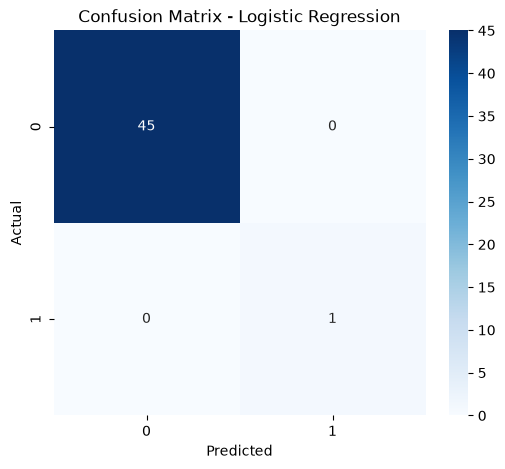

In [57]:
if best_model_name in [
    "Logistic Regression",
    "MLP"
]:
    best_X_test = X_test_scaled
else:
    best_X_test = X_test

best_predictions = best_model.predict(
    best_X_test
)

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

In [58]:
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "No Flood",
            "Flood"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00        45
       Flood       1.00      1.00      1.00         1

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46



In [59]:
if best_model_name in [
    "Logistic Regression",
    "MLP"
]:

    probabilities = best_model.predict_proba(
        X_test_scaled
    )[:, 1]

else:

    probabilities = best_model.predict_proba(
        X_test
    )[:, 1]

In [60]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions,
    "Flood_Probability": probabilities
})

display(prediction_results)

,Actual,Predicted,Flood_Probability
0,0,0,0.009428
1,0,0,0.009361
2,0,0,0.005729
3,0,0,0.004985
4,0,0,0.010349
5,0,0,0.009052
6,0,0,0.004143
7,0,0,0.003800
8,0,0,0.006069
9,0,0,0.003468


In [61]:
def flood_risk_level(probability):

    if probability < 0.20:
        return "LOW"

    elif probability < 0.40:
        return "MODERATE"

    elif probability < 0.60:
        return "HIGH"

    elif probability < 0.80:
        return "VERY HIGH"

    else:
        return "EXTREME"

In [62]:
prediction_results["Risk_Level"] = (
    prediction_results["Flood_Probability"]
    .apply(flood_risk_level)
)

display(prediction_results)

,Actual,Predicted,Flood_Probability,Risk_Level
0,0,0,0.009428,LOW
1,0,0,0.009361,LOW
2,0,0,0.005729,LOW
3,0,0,0.004985,LOW
4,0,0,0.010349,LOW
5,0,0,0.009052,LOW
6,0,0,0.004143,LOW
7,0,0,0.003800,LOW
8,0,0,0.006069,LOW
9,0,0,0.003468,LOW


In [63]:
if best_model_name == "XGBoost":

    importance = pd.DataFrame({
        "Feature": numeric_features,
        "Importance": xgb_model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    display(importance)

In [64]:
if best_model_name == "XGBoost":

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("XGBoost Feature Importance")

    plt.gca().invert_yaxis()

    plt.show()

In [65]:
imputer_path = os.path.join(
    MODEL_DIR,
    "historical_flood_imputer.pkl"
)

scaler_path = os.path.join(
    MODEL_DIR,
    "historical_flood_scaler.pkl"
)

joblib.dump(
    imputer,
    imputer_path
)

joblib.dump(
    scaler,
    scaler_path
)

print("✅ Imputer saved:", imputer_path)
print("✅ Scaler saved:", scaler_path)

✅ Imputer saved: E:\MY projects\Flash Flood Prediction Project\models\Historical_Flood\historical_flood_imputer.pkl
✅ Scaler saved: E:\MY projects\Flash Flood Prediction Project\models\Historical_Flood\historical_flood_scaler.pkl


In [66]:
logistic_path = os.path.join(
    MODEL_DIR,
    "historical_flood_logistic.pkl"
)

joblib.dump(
    logistic_model,
    logistic_path
)

print("✅ Logistic Regression saved")

✅ Logistic Regression saved


In [67]:
rf_path = os.path.join(
    MODEL_DIR,
    "historical_flood_random_forest.pkl"
)

joblib.dump(
    rf_model,
    rf_path
)

print("✅ Random Forest saved")

✅ Random Forest saved


In [68]:

xgb_path = os.path.join(
    MODEL_DIR,
    "historical_flood_xgboost.json"
)

xgb_model.save_model(
    xgb_path
)

print("✅ XGBoost saved!")
print("📁", xgb_path)

✅ XGBoost saved!
📁 E:\MY projects\Flash Flood Prediction Project\models\Historical_Flood\historical_flood_xgboost.json


In [69]:
mlp_path = os.path.join(
    MODEL_DIR,
    "historical_flood_mlp.pkl"
)

joblib.dump(
    mlp_model,
    mlp_path
)

print("✅ MLP saved")

✅ MLP saved


In [70]:
best_model_name = "Random Forest"
best_model = rf_model

print("🏆 Selected Best Model:", best_model_name)

🏆 Selected Best Model: Random Forest


In [71]:
best_model_path = os.path.join(
    MODEL_DIR,
    "historical_flood_best_model.pkl"
)

joblib.dump(
    best_model,
    best_model_path
)

print("✅ Best Historical Flood Model Saved!")
print("📁", best_model_path)

✅ Best Historical Flood Model Saved!
📁 E:\MY projects\Flash Flood Prediction Project\models\Historical_Flood\historical_flood_best_model.pkl
